In [ ]:
!pip install trimesh -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 750.0/750.0 kB 9.0 MB/s eta 0:00:00


In [ ]:
import json
import os

from google.colab import drive
drive.mount('/content/drive')

save_dir = '/content/drive/MyDrive/pointcloud/params'

# Create the directory if it doesn't already exist
os.makedirs(save_dir, exist_ok=True)

file_path = os.path.join(save_dir, 'parameters.json')

# 1. Define your program parameters in a dictionary
parameters = {
    "pixel_pitch": 3.74e-6,
    "wavelength": 632.8e-9,
    "axis_dist": 0.9999,
    "img_width": 3840,
    "img_height": 2180,
    "target_vram_gb": 10.0,
    "generate_hologram": True,
    "optimize_gs": True,
    "img_path": "/content/drive/MyDrive/pointcloud/CGHs/zmienNazwe.png",
}

# 2. Save the parameters to a JSON file
with open(file_path, "w") as json_file:
    # indent=4 formats the file to be easily readable by humans
    json.dump(parameters, json_file, indent=4)

print("Parameters successfully saved to: ",file_path)

Mounted at /content/drive
Parameters successfully saved to:  /content/drive/MyDrive/pointcloud/params/parameters.json


In [ ]:
params_path = '/content/drive/MyDrive/pointcloud/params/parameters.json'

with open(params_path, "r") as json_file:
    loaded_params = json.load(json_file)

# Load the global program parameters

pixel_pitch = loaded_params["pixel_pitch"]
wavelength = loaded_params["wavelength"]
axis_dist = loaded_params["axis_dist"]
width = loaded_params["img_width"]
height = loaded_params["img_height"]
target_vram_gb = loaded_params["target_vram_gb"]
generate_hologram = loaded_params["generate_hologram"]
optimize_gs = loaded_params["optimize_gs"]
img_path = loaded_params["img_path"]

# instrukcja warunkowa optymalizacji GS
if generate_hologram != True:
    optimize_gs = False
    print("Tryb odczytu jest włączony. Ustaw generate_holograms na TRUE")

In [ ]:
!pip install moderngl trimesh pyrr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.2/296.2 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.2/51.2 kB 6.2 MB/s eta 0:00:00


In [ ]:
import trimesh
import torch
import numpy as np
import plotly.graph_objects as go
import matplotlib.pyplot as plt


# 1. Load the mesh (ensure process=False so UVs map 1:1 with vertices)
filename = "/content/drive/MyDrive/pointcloud/Eta2/Eta2_whole.obj"
mesh = trimesh.load(filename, force='mesh', process=False)

# 2. Apply your existing rotation
rx, ry, rz = np.radians(90), np.radians(-90), np.radians(0)
euler_matrix = trimesh.transformations.euler_matrix(rx, ry, rz, 'rxyz')
mesh.apply_transform(euler_matrix)

# 3. Setup GPU Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Move vertices and UV coordinates to the GPU
vertices_gpu = torch.tensor(mesh.vertices, dtype=torch.float32, device=device)
uvs_gpu = torch.tensor(mesh.visual.uv, dtype=torch.float32, device=device)

# 4. Load and process the texture image
# Note: Ensure the texture image matches your .mtl file definition
texture_pil = mesh.visual.material.image
texture_array = np.array(texture_pil) / 255.0  # Normalize to [0, 1]
texture_gpu = torch.tensor(texture_array, dtype=torch.float32, device=device)

# 5. UV Mapping Algorithm on GPU
# PyTorch grid_sample expects a grid range of [-1, 1]
# We flip the V coordinate as images load top-to-bottom
uvs_gpu[:, 1] = 1.0 - uvs_gpu[:, 1]
grid = (uvs_gpu * 2.0) - 1.0

# Reshape inputs for grid_sample: Image to [1, C, H, W] and Grid to [1, 1, N, 2]
grid = grid.view(1, 1, -1, 2)
tex_chw = texture_gpu.permute(2, 0, 1).unsqueeze(0)

# Perform bilinear interpolation on the GPU to extract colors for each point
colors_gpu = torch.nn.functional.grid_sample(tex_chw, grid, align_corners=True)
colors_gpu = colors_gpu.squeeze().transpose(0, 1) # Reshape back to [N, C]

# 6. Convert back to CPU for visualization
vertices = vertices_gpu.cpu().numpy()
colors = (colors_gpu.cpu().numpy() * 255).astype(np.uint8)
faces = mesh.faces

# 7. Plot with Plotly

# Extract the face indices to connect the vertices[cite: 2]
i, j, k = mesh.faces.T

# Construct Plotly Mesh with vertex colors
vertex_str_colors = [f'rgb({c[0]},{c[1]},{c[2]})' for c in colors]

fig = go.Figure(data=[go.Mesh3d(
    x=vertices[:, 0], y=vertices[:, 1], z=vertices[:, 2],
    i=i, j=j, k=k,
    vertexcolor=vertex_str_colors,
    opacity=1.0,
)])

fig.update_layout(margin=dict(l=0, r=0, b=0, t=0))
fig.show()

In [ ]:
typ = faces.dtype

print("Typ danych macierzy to:", typ)

Typ danych macierzy to: int64


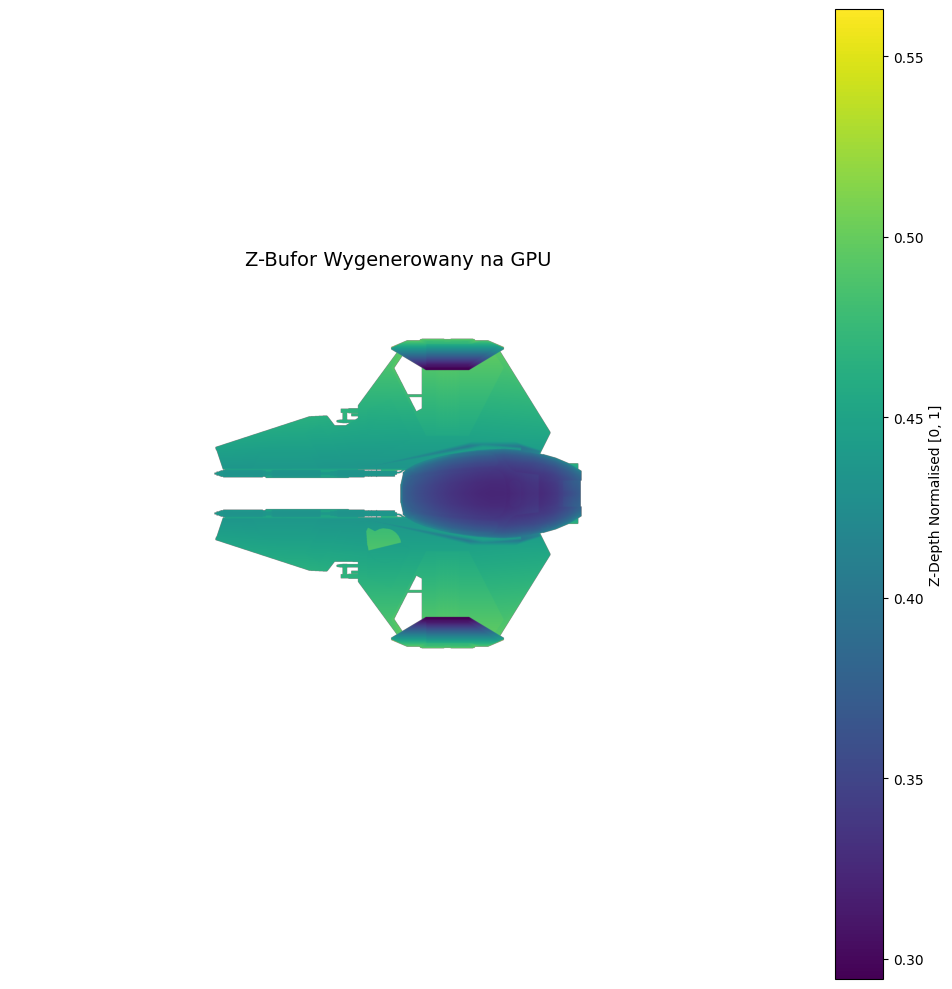

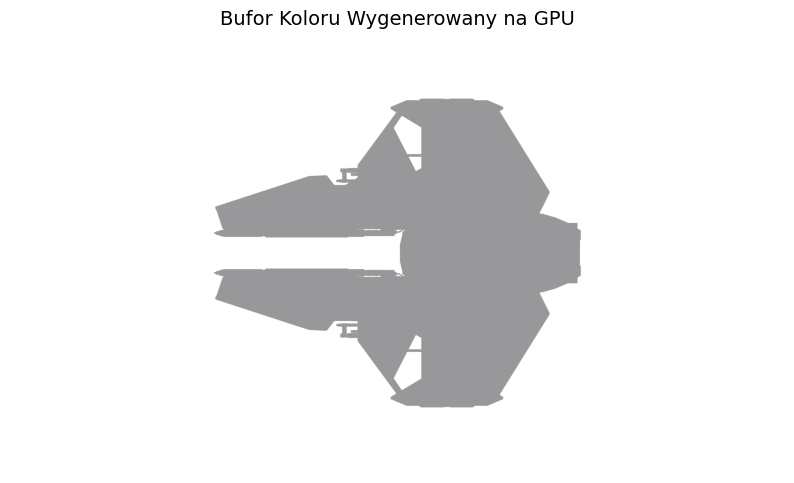

In [ ]:
from pyrr import Matrix44 # Lekka biblioteka do macierzy transformacji
import moderngl

# =====================================================================
# KROK 2: INICJALIZACJA KONTEKSTU GPU (Headless)
# =====================================================================
# Tworzymy niezależny kontekst OpenGL bez otwierania okna systemu operacyjnego
ctx = moderngl.create_context(standalone=True, backend='egl')
ctx.enable(moderngl.DEPTH_TEST) # Włączenie sprzętowego Z-bufora

# =====================================================================
# KROK 3: SHADERY (Programy wykonywane bezpośrednio na rdzeniach GPU)
# =====================================================================

# Vertex Shader
vertex_shader = '''
#version 330
in vec3 in_position;
in vec2 in_uv;          // NOWOŚĆ: Współrzędne tekstury
uniform mat4 ortho_matrix;
out vec2 v_uv;          // NOWOŚĆ: Przekazanie UV do Fragment Shadera

void main() {
    gl_Position = ortho_matrix * vec4(in_position, 1.0);
    v_uv = in_uv;
}
'''

# Fragment Shader
fragment_shader = '''
#version 330
in vec2 v_uv;                 // NOWOŚĆ: Otrzymane UV
uniform sampler2D Texture;    // NOWOŚĆ: Tekstura modelu
out vec4 fragColor;

void main() {
    float depth = gl_FragCoord.z;
    vec3 color = texture(Texture, v_uv).rgb; // Pobranie koloru z tekstury

    // NOWOŚĆ: Zapisujemy RGB do pierwszych 3 kanałów, a Depth do 4-go kanału
    fragColor = vec4(color, depth);
}
'''

prog = ctx.program(vertex_shader=vertex_shader, fragment_shader=fragment_shader)

x_min, y_min, z_min = vertices.min(axis=0)
x_max, y_max, z_max = vertices.max(axis=0)

# =====================================================================
# KROK 4: MACIERZ ORTOGRAFICZNA (Z kompensacją Aspect Ratio)
# =====================================================================
x_range = x_max - x_min
y_range = y_max - y_min
z_range = z_max - z_min
# Używamy pełnego zakresu modelu z marginesem 20%, tak jak w kodzie CPU
max_range = max(x_range, y_range, z_range) * 1.2

# Odtwarzamy idealną, jednorodną skalę z kodu programowego CPU
scale = min(width, height) / max_range

# Zamiast przypisywać sztywny 'max_range' do osi X i Y,
# dostosowujemy rozpiętość kamery do fizycznych pikseli bufora.
# To gwarantuje zachowanie proporcji nawet na asymetrycznych ekranach.
x_span = width / (2.0 * scale)
y_span = height / (2.0 * scale)

# Oś Z nie podlega sprzętowemu dopasowaniu do ekranu (Viewport Transform),
# więc jej rozpiętość zostawiamy zgodnie z gabarytami modelu (połowa zakresu).
z_span = max_range / 2.0

x_center = (x_max + x_min) / 2.0
y_center = (y_max + y_min) / 2.0
z_center = (z_max + z_min) / 2.0

near_plane = z_center - z_span
far_plane = z_center + z_span

# centrowanie obiektu


# Generujemy asymetryczną macierz rzutowania, która anuluje błędy pikseli prostokątnych
ortho_matrix = Matrix44.orthogonal_projection(
    x_center - x_span, x_center + x_span,  # left, right
    y_center - y_span, y_center + y_span,  # bottom, top
    near_plane, far_plane                  # near, far
).astype('f4')

prog['ortho_matrix'].write(ortho_matrix.tobytes())

from PIL import Image

# ... (KROK 4 pozostaje bez zmian) ...

# =====================================================================
# KROK 5: BUFORY GPU (VBO, IBO, FBO) I TEKSTURY
# =====================================================================

# 1. Wczytanie tekstury modelu (Główna mapa kolorów Eta2)
tex_path = "/content/drive/MyDrive/pointcloud/Eta2/Textures/Eta2.png"
img = Image.open(tex_path).convert('RGB')
# OpenGL czyta tekstury od dołu do góry, więc musimy ją odwrócić
img = img.transpose(Image.FLIP_TOP_BOTTOM)

texture = ctx.texture(img.size, 3, img.tobytes())
texture.use(location=0)      # Przypisujemy teksturę do slotu 0
prog['Texture'].value = 0    # Informujemy shader, że tekstura jest w slocie 0

# 2. Przerzucamy wierzchołki, UV i indeksy z RAM do VRAM
uvs = mesh.visual.uv.astype('f4') # Wyciągamy UV z modelu Trimesh

vbo = ctx.buffer(vertices.tobytes()) #Bufor na wierzchołki siatki
uv_vbo = ctx.buffer(uvs.tobytes()) # Bufor na współrzędne UV
ibo = ctx.buffer(faces.astype('i4').tobytes()) # tablica indeksów

# NOWOŚĆ: Rejestrujemy oba bufory (Pozycja i UV) w VAO
vao = ctx.vertex_array(prog, [
    (vbo, '3f', 'in_position'),
    (uv_vbo, '2f', 'in_uv')
], index_buffer=ibo)

# 3. Tworzymy Framebuffer Object (FBO) - pozostaje bez zmian
color_renderbuffer = ctx.renderbuffer((width, height), components=4, dtype='f4')
depth_renderbuffer = ctx.depth_renderbuffer((width, height))
fbo = ctx.framebuffer(color_attachments=[color_renderbuffer], depth_attachment=depth_renderbuffer)
fbo.use()

# =====================================================================
# KROK 6: RASTERYZACJA SPRZĘTOWA
# =====================================================================
# Tło: RGB = Czarny, Alpha(Depth) = 1.0
fbo.clear(red=0.0, green=0.0, blue=0.0, alpha=1.0, depth=1.0)
vao.render(moderngl.TRIANGLES)

# =====================================================================
# KROK 7: POBRANIE WYNIKÓW Z VRAM DO NUMPY
# =====================================================================
raw_data = fbo.read(components=4, dtype='f4')
buffer_data = np.frombuffer(raw_data, dtype='f4').reshape((height, width, 4))
buffer_data = np.flipud(buffer_data)

# NOWOŚĆ: Rozdzielamy spakowane dane!
color_buffer = buffer_data[:, :, :3]  # Kanały RGB (0, 1, 2) to nasz Kolor
z_buffer = buffer_data[:, :, 3]       # Kanał Alpha (3) to nasza Głębokość

# =====================================================================
# WIZUALIZACJA
# =====================================================================
plt.figure(figsize=(10, 10))
masked_z = np.ma.masked_where(z_buffer >= 0.9999, z_buffer)
plt.imshow(masked_z, cmap='viridis')
plt.title("Z-Bufor Wygenerowany na GPU", fontsize=14)
plt.colorbar(label='Z-Depth Normalised [0, 1]')
plt.axis('off')
plt.tight_layout()
plt.show()

# Wizualizacja Koloru
plt.figure(figsize=(10, 10))
# Musimy nałożyć maskę na 3 kanały (RGB), aby usunąć czarne tło (jeśli jest potrzebne)
masked_color = np.copy(color_buffer)
masked_color[z_buffer >= 0.9999] = [1.0, 1.0, 1.0] # Białe tło dla czytelności
plt.imshow(masked_color)
plt.title("Bufor Koloru Wygenerowany na GPU", fontsize=14)
plt.axis('off')
plt.show()


/tmp/ipykernel_4522/3191560150.py:7: DeprecationWarning:

'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)



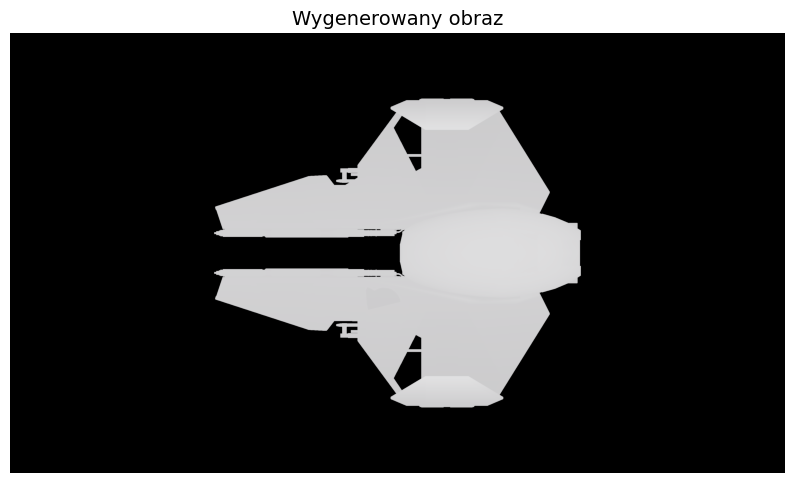

In [ ]:
# 1. Przeskalowanie wartości z przedziału [0.0, 1.0] do [0, 255]
# Jeśli Twoje dane z OpenGL są w innym formacie i mają już wartości 0-255, pomin to mnożenie.
image_data_uint8 = (buffer_data * 255).astype(np.uint8)

# 2. Utworzenie obiektu obrazu na podstawie tablicy NumPy
# Mode 'RGBA' oznacza, że mamy 4 kanały: Red, Green, Blue, Alpha
image = Image.fromarray(image_data_uint8, mode='RGBA')

plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.title("Wygenerowany obraz", fontsize=14)
plt.axis('off')
plt.show()


In [ ]:
pip install moderngl-window pyrr Pillow numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 382.4/382.4 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 100.5 MB/s eta 0:00:00


In [ ]:
import numpy as np
import trimesh

# =====================================================================
# KROK 7: ZAPIS CHMURY PUNKTÓW DO PLIKU PLY (Architektura GPU)
# =====================================================================

# 1. Identyfikacja poprawnych fragmentów.
# Szukamy pikseli, gdzie Z jest mniejsze niż 1.0 (tło).
# Używamy tolerancji < 0.9999 z powodu specyfiki zapisu zmiennoprzecinkowego
# w pamięci VRAM (Depth24/Depth32F), aby uniknąć błędów zaokrągleń (floating point inaccuracies).
valid_y, valid_x = np.where(z_buffer < 0.9999)

# 2. Ekstrakcja głębokości z bufora
valid_z_normalized = z_buffer[valid_y, valid_x]

# 2.1. Ekstrakcja amplitudy dla usuniętych punktów
valid_color = color_buffer[valid_y, valid_x]

# =====================================================================
# UWAGA INŻYNIERYJNA: REKONSTRUKCJA GŁĘBOKOŚCI
# Zmienna `valid_z_normalized` przechowuje wartości od 0.0 do 1.0.
# Jeśli wstawisz je bezpośrednio obok `valid_x` (np. 500 px) i `valid_y`,
# Twoja chmura punktów będzie drastycznie "spłaszczona" na osi Z.
#
# Aby przywrócić pierwotne proporcje (World Space), musimy odwrócić
# sprzętowe rzutowanie, korzystając z parametrów `near` i `far`,
# których użyliśmy w macierzy `ortho_matrix` (od -1000.0 do +1000.0).
# =====================================================================
# Mapowanie liniowe z [0, 1] powrót do skali obiektu

# 1. Dekompresja sprzętowa: powrót z [0, 1] do rzeczywistych jednostek świata
valid_z_world_absolute = (valid_z_normalized * (far_plane - near_plane)) + near_plane

# 2. Przejście do przestrzeni "pikseli" (aby zrównać proporcje z osiami X i Y)
# Używamy tej samej skali (scale), którą obliczyliśmy na początku dla ekranu.
valid_z_pixel_space = (valid_z_world_absolute - z_center) * scale

# 3. Budowa macierzy punktów o jednorodnych jednostkach (wszystko w skali ekranu)
point_cloud_array = np.column_stack((valid_x, valid_y, valid_z_pixel_space))

#=========NOWOSC=========

# KONWERSJA AMPLITUDY DO SKALI SZAROŚCI W FORMACIE PLY (RGB/RGBA)
# Zmieniamy wartość 0.0-1.0 na 0-255 uint8 dla formatu koloru wierzchołków (Vertex Colors).
# Zdecydowana większość programów (np. CloudCompare) tak odczytuje intensywność.
amplitudes_8bit = (np.clip(valid_color, 0.0, 1.0) * 255).astype(np.uint8)

print(f"\nWygenerowano chmurę punktów z GPU Z-bufora! Liczba punktów: {len(point_cloud_array)}")

# 4. Inicjalizacja struktury i serializacja do pliku .ply
ply_filename = "/content/drive/MyDrive/pointcloud/zmienNazwe_gpu_kolor.ply"
pcd = trimesh.points.PointCloud(point_cloud_array, colors=valid_color)
pcd.export(ply_filename)

print(f"Pomyślnie zapisano sprzętową chmurę punktów do pliku: {ply_filename}")


Wygenerowano chmurę punktów z GPU Z-bufora! Liczba punktów: 1559129
Pomyślnie zapisano sprzętową chmurę punktów do pliku: /content/drive/MyDrive/pointcloud/zmienNazwe_gpu_kolor.ply
